# Copy-Paste Data Augmentation

Le pipeline devra :

1. segmenter les bêtes présentes dans les crops ;
2. les placer aléatoirement sur de nouveaux fonds ;
3. générer les bounding boxes et les labels YOLO ;
4. sauvegarder les nouvelles images de détection.

Ce notebook commence uniquement par la première partie : comparer simplement plusieurs méthodes de segmentation.


# Partie 1 — Segmentation

Modifier uniquement IMAGE_PATH pour tester toutes les méthodes sur un autre crop.


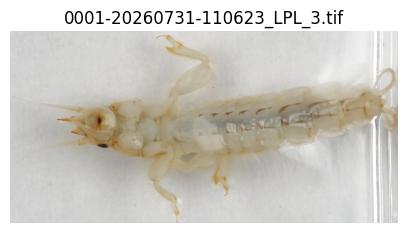

In [20]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


IMAGE_PATH = Path(
    "../../datasets/LPL_dataset_crop/"
    "Arthropoda_Insecta_Ephemeroptera_Polymitarcidae_Ephemera_sp/"
    "0001-20260731-110623_LPL_3.tif"
)

image = np.asarray(Image.open(IMAGE_PATH).convert("RGB"))

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(IMAGE_PATH.name)
plt.axis("off")
plt.show()


In [21]:
def show_mask(image, mask, title):
    """Affiche l'image, le masque et le détourage sur fond blanc."""
    cutout = np.where(mask[..., None], image, 255)

    figure, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(title)
    axes[2].imshow(cutout)
    axes[2].set_title("Détourage")

    for axis in axes:
        axis.axis("off")
    plt.show()


## Méthode 1 — Seuillage d'Otsu

**Avantages**

- très rapide ;
- aucun modèle à télécharger ;
- bon résultat si la bête est foncée sur un fond clair.

**Inconvénients**

- moins adapté aux bêtes translucides ;
- sensible aux ombres et aux variations du fond.


In [22]:
def mask_otsu(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    _, mask = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    return mask > 0


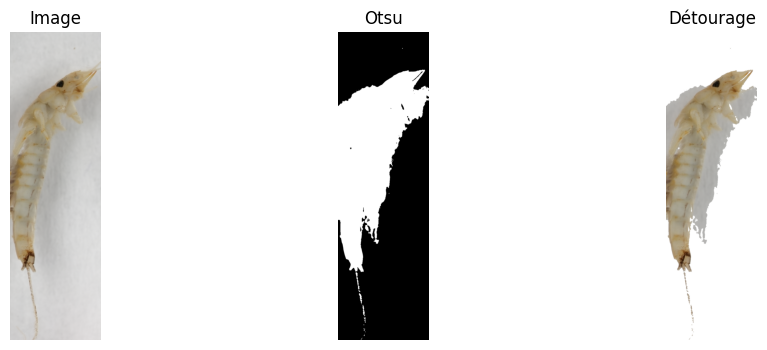

In [44]:
otsu_mask = mask_otsu(image)
show_mask(image, otsu_mask, "Otsu")


## Méthode 2 — Distance avec la couleur du fond

La couleur du fond est estimée avec les pixels situés sur les bords du crop.
On conserve ensuite les pixels dont la couleur est différente du fond.

**Avantages**

- prend en compte la couleur, contrairement à Otsu ;
- reste rapide et sans modèle ;
- généralement mieux adapté aux fonds blancs ou gris de ce dataset.

**Inconvénients**

- fonctionne moins bien si la bête touche fortement les bords ;
- peut perdre les parties très transparentes.


In [24]:
def mask_background_color(image, border_size=5):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB).astype(np.float32)

    border_pixels = np.concatenate([
        lab[:border_size].reshape(-1, 3),
        lab[-border_size:].reshape(-1, 3),
        lab[:, :border_size].reshape(-1, 3),
        lab[:, -border_size:].reshape(-1, 3),
    ])

    background_color = np.median(border_pixels, axis=0)
    distance = np.linalg.norm(lab - background_color, axis=2)
    distance = np.clip(distance, 0, 255).astype(np.uint8)

    _, mask = cv2.threshold(
        distance, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return mask > 0


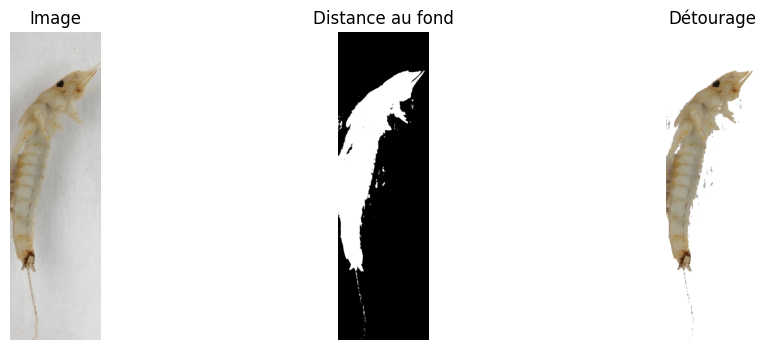

In [45]:
background_mask = mask_background_color(image)
show_mask(image, background_mask, "Distance au fond")


## Méthode 3 — GrabCut

GrabCut sépare le premier plan et le fond à partir d'un premier masque.
Ici, le masque de couleur précédent sert simplement d'amorce.

**Avantages**

- peut améliorer les contours du masque précédent ;
- utilise les couleurs du premier plan et du fond ;
- ne nécessite pas de GPU.

**Inconvénients**

- plus lent que les deux seuillages ;
- dépend directement de la qualité du masque initial ;
- peut supprimer les pattes ou antennes très fines.


In [14]:
def mask_grabcut(image):
    initial_mask = mask_background_color(image)

    grabcut_mask = np.full(image.shape[:2], cv2.GC_PR_BGD, dtype=np.uint8)
    grabcut_mask[initial_mask] = cv2.GC_PR_FGD

    # Quelques pixels certains pour initialiser les deux modèles de couleur.
    grabcut_mask[[0, -1], :] = cv2.GC_BGD
    grabcut_mask[:, [0, -1]] = cv2.GC_BGD

    foreground = cv2.erode(initial_mask.astype(np.uint8), None, iterations=1)
    grabcut_mask[foreground > 0] = cv2.GC_FGD

    background_model = np.zeros((1, 65), dtype=np.float64)
    foreground_model = np.zeros((1, 65), dtype=np.float64)

    cv2.grabCut(
        cv2.cvtColor(image, cv2.COLOR_RGB2BGR),
        grabcut_mask,
        None,
        background_model,
        foreground_model,
        5,
        cv2.GC_INIT_WITH_MASK,
    )

    return np.isin(grabcut_mask, [cv2.GC_FGD, cv2.GC_PR_FGD])


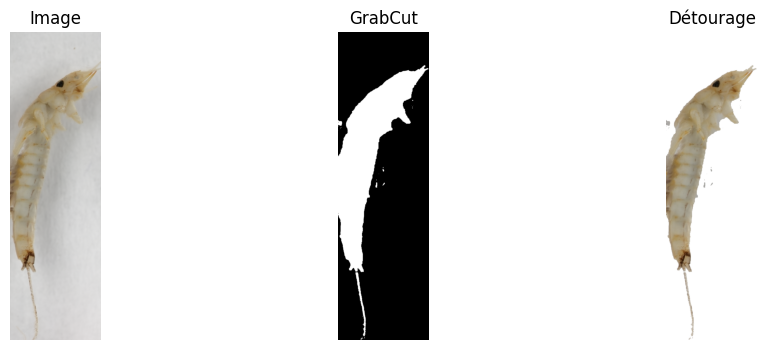

In [46]:
grabcut_mask = mask_grabcut(image)
show_mask(image, grabcut_mask, "GrabCut")


## Comparaison des trois méthodes classiques

Cette cellule permet de voir rapidement les trois masques sur la même ligne.
Pour tester un autre crop, modifier IMAGE_PATH au début puis relancer les cellules.


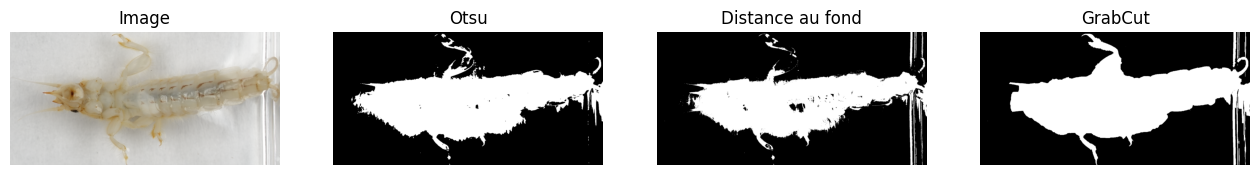

In [27]:
classical_masks = {
    "Otsu": mask_otsu(image),
    "Distance au fond": mask_background_color(image),
    "GrabCut": mask_grabcut(image),
}

figure, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image)
axes[0].set_title("Image")

for axis, (name, mask) in zip(axes[1:], classical_masks.items()):
    axis.imshow(mask, cmap="gray")
    axis.set_title(name)

for axis in axes:
    axis.axis("off")
plt.show()


## Méthode 4 — SAM 2.1

SAM 2.1 est une méthode moderne de segmentation avec prompt. On lui donne une
boîte correspondant presque à tout le crop.

**Avantages**

- adaptée aux formes complexes ;
- peut mieux gérer les objets translucides ;
- ne nécessite pas d'entraînement initial sur nos données.

**Inconvénients**

- télécharge un checkpoint ;
- GPU fortement conseillé ;
- beaucoup plus lente ;
- peut sélectionner un étui ou des débris avec la bête.

Cette partie est indépendante. Exécuter les cellules suivantes uniquement pour tester SAM.


In [17]:
import torch
from transformers import Sam2Model, Sam2Processor


SAM_MODEL_ID = "facebook/sam2.1-hiera-tiny"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam_processor = Sam2Processor.from_pretrained(SAM_MODEL_ID)
sam_model = Sam2Model.from_pretrained(SAM_MODEL_ID).to(device).eval()

print("SAM chargé sur", device)


/home/benjamin.yang/Documents/AKKODIS/AquaIA/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
Loading weights: 100%|██████████| 309/309 [00:00<00:00, 4770.59it/s]

SAM chargé sur cpu


In [42]:
def mask_sam2(image, invert=True):
    height, width = image.shape[:2]
    box = [[[2, 2, width - 3, height - 3]]]

    inputs = sam_processor(
        images=Image.fromarray(image),
        input_boxes=box,
        return_tensors="pt",
    ).to(device)

    with torch.inference_mode():
        outputs = sam_model(**inputs)

    masks = sam_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"],
    )[0]

    best_mask = outputs.iou_scores[0, 0].argmax().item()
    mask = masks[0, best_mask].numpy().astype(bool)
    return ~mask if invert else mask


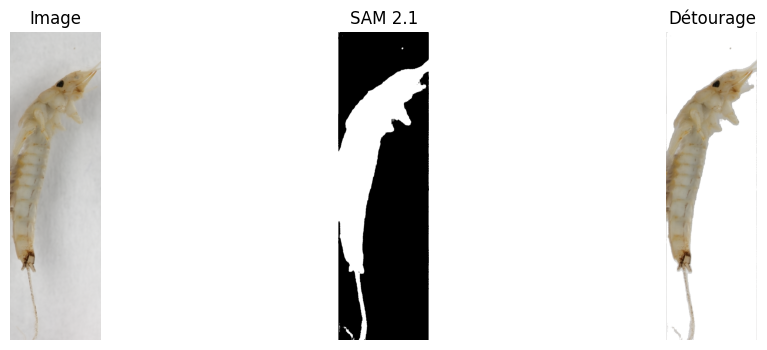

In [43]:
sam_mask = mask_sam2(image)
show_mask(image, sam_mask, "SAM 2.1")


## Conclusion provisoire

- **Otsu** : baseline la plus simple.
- **Distance au fond** : meilleur candidat classique pour commencer.
- **GrabCut** : à utiliser si le masque précédent a besoin d'être raffiné.
- **SAM 2.1** : candidat pour les bêtes translucides et les cas difficiles.

Une fois la méthode choisie, on pourra ajouter un nettoyage morphologique simple
et passer à la partie Copy-Paste.
